# CTCF stripes: XPC noUV vs WT noUV (convergent stripe stackups)

coolpuppy stripe-stackup recipe (API walkthrough) for **clear** stripes:
- `by_strand=True`, pairwise CTCF within `mindist`–`maxdist`, **not** `local` (local folds the stripe).
- keep **convergent (strand1='+', strand2='−')** pairs — the actual stripe/loop anchors.
- `store_stripes` → per-pair stripe lines → **sorted stripe stackup** (where individual stripes are visible; the averaged 2D pileup is always faint).
- **strong CTCF anchors** (top motif score) sharpen the stripe.

Anchors = CTCF sites occupied in **both** WT and XPC (shared IDR peaks), strand+score from the
overlapping CTCF motif → identical sites in both samples. Differential = **log2(XPC/WT)** on the
convergent stripe (per-sample obs/exp).

In [1]:
import os
import numpy as np
import pandas as pd
import bioframe as bf
import bbi
import matplotlib.pyplot as plt
from coolpuppy import coolpup
from scipy.stats import mannwhitneyu

from ggner_3d.cm import CLR_CONNS, get_expected_cis_df, prepare_view_df
from ggner_3d import plotting
plotting.update_rcparams()

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

NPROC = 8
resolution = 10_000
MINDIST = 100_000
MAXDIST = 1_000_000
FLANK = 300_000

# IDR reproducibility filter: narrowPeak col5 score >= 540  <=>  IDR <= 0.05
# (540 = -125*log2(0.05)). Removes irreproducible peaks before anchoring.
IDR_MIN_SCORE = 540

# Further anchor refinement (optional): keep CTCF sites TOP-QUARTILE in BOTH motif score
# AND CTCF ChIP signal (FC_score), then cap to the strongest FINAL_TOP_N by ChIP.
SELECT_TOP_BOTH = True
FINAL_TOP_N = 5000
TOP_N_BY_MOTIF = 5000
FC_FLANK = 250
STRENGTH_LO_KB, STRENGTH_HI_KB = 20, 150

# CTCF ChIP rpgc bigwigs for the BASE condition (WT noUV) -> FC_score
CTCF_BW = [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP2.mLb.clN.rpgc.bw',
]

BASE, COMP = 'WTnoUV', 'XPCnoUV'
BASE_CTCF = '/home/carlos/oldies/ner_collab/ctcf/idr/WT_NoUV_idr_conservative_merged.narrowPeak'
COMP_CTCF = '/home/carlos/oldies/ner_collab/ctcf/idr/XPCKO_NoUV_idr_conservative_merged.narrowPeak'
MOTIF    = '/home/carlos/Clone/ggner-3d/data/CTCF_hg38.bed'
STD_CHROMS = [f'chr{c}' for c in list(range(1, 23)) + ['X']]

clr_ = CLR_CONNS(resolution=resolution)
view_df = prepare_view_df(arm=True)
expected_ = {k: get_expected_cis_df(k, resolution_kb=resolution // 1000, label='arm') for k in [BASE, COMP]}

## 1. Strong shared CTCF sites (BASE ∩ COMP), strand+score from motif

In [2]:
def read_peaks(path):
    # narrowPeak cols: chrom start end name SCORE strand signalValue pValue qValue peak
    df = pd.read_csv(path, sep='\t', header=None, usecols=[0, 1, 2, 4],
                     names=['chrom', 'start', 'end', 'score'])
    df = df[(df['chrom'].isin(STD_CHROMS)) & (df['score'] >= IDR_MIN_SCORE)].copy()
    return bf.merge(df.sort_values(['chrom', 'start']))[['chrom', 'start', 'end']]

base_p, comp_p = read_peaks(BASE_CTCF), read_peaks(COMP_CTCF)
shared = bf.overlap(base_p, comp_p, how='inner', return_overlap=True)[['chrom', 'start', 'end']]
shared = shared.drop_duplicates().reset_index(drop=True)
shared['mid'] = (shared['start'] + shared['end']) // 2

# strongest overlapping CTCF motif -> strand + motif score.
# CTCF_hg38.bed cols: chrom start end <int> strand name SCORE pval qval seq  (score = col idx 6)
motif = pd.read_csv(MOTIF, sep='\t', header=None,
                    names=['chrom', 'start', 'end', 'x3', 'strand', 'name', 'mscore', 'pval', 'qval', 'seq'])
motif = motif[motif['chrom'].isin(STD_CHROMS)][['chrom', 'start', 'end', 'strand', 'mscore']]
shared['idx'] = np.arange(len(shared))
ov = bf.overlap(shared[['chrom', 'start', 'end', 'idx']], motif, how='inner', suffixes=('', '_m'))
best = ov.sort_values('mscore_m', ascending=False).drop_duplicates('idx')[['idx', 'strand_m', 'mscore_m']]
shared = shared.merge(best, on='idx', how='inner')

# CTCF ChIP FC_score = mean rpgc signal over +/- FC_FLANK around the anchor (mean of reps)
chroms = shared['chrom'].tolist()
mids = shared['mid'].astype(int).values
starts = np.clip(mids - FC_FLANK, 0, None).tolist()
ends = (mids + FC_FLANK).tolist()
fc = np.zeros(len(shared))
for bw in CTCF_BW:
    fc += bbi.stackup(bw, chroms, starts, ends, bins=1, summary='mean', missing=0.0).flatten()
shared['FC_score'] = fc / len(CTCF_BW)

# optional refinement on top of the IDR filter
if SELECT_TOP_BOTH:
    shared['q_motif'] = pd.qcut(shared['mscore_m'], 4, labels=False, duplicates='drop') + 1
    shared['q_fc'] = pd.qcut(shared['FC_score'], 4, labels=False, duplicates='drop') + 1
    shared = shared[(shared['q_motif'] == shared['q_motif'].max()) &
                    (shared['q_fc'] == shared['q_fc'].max())].copy()
    if FINAL_TOP_N is not None and FINAL_TOP_N < len(shared):
        shared = shared.nlargest(FINAL_TOP_N, 'FC_score').copy()
    sel = f'IDR>={IDR_MIN_SCORE} + top-quartile by BOTH motif & ChIP (cap {FINAL_TOP_N})'
else:
    shared = shared.nlargest(TOP_N_BY_MOTIF, 'mscore_m').copy()
    sel = f'IDR>={IDR_MIN_SCORE} + top {TOP_N_BY_MOTIF} by motif score'
shared = shared.sort_values(['chrom', 'start']).reset_index(drop=True)

sites = pd.DataFrame({
    'chrom': shared['chrom'].values,
    'start': shared['mid'].astype(int).values,
    'end': shared['mid'].astype(int).values + resolution,
    'strand': shared['strand_m'].values,
})
print(f'{BASE} peaks(IDR>={IDR_MIN_SCORE}) {len(base_p)}, {COMP} {len(comp_p)}; selection = {sel} -> {len(sites)} anchors')
print(f'selected CTCF ChIP FC median {shared.FC_score.median():.1f}  motif score median {shared.mscore_m.median():.1f}')
print(sites['strand'].value_counts())

WTnoUV peaks(IDR>=540) 35409, XPCnoUV 24322; selection = IDR>=540 + top-quartile by BOTH motif & ChIP (cap 5000) -> 2388 anchors
selected CTCF ChIP FC median 102.4  motif score median 21.6
strand
+    1201
-    1187
Name: count, dtype: int64


## 2. Stripe pileups (by_strand, store_stripes) → convergent (+,−)

In [3]:
def stripe_pileup(clrname, expected):
    return coolpup.pileup(
        clr_[clrname], sites, features_format='bed', view_df=view_df,
        expected_df=expected, clr_weight_name='sweight', ooe=True,
        by_strand=True, mindist=MINDIST, maxdist=MAXDIST, flank=FLANK,
        store_stripes=True, nproc=NPROC,
    )

# per-sample obs/exp (each sample / its own expected) -- field-standard cross-sample comparison
pup = {s: stripe_pileup(s, expected_[s]) for s in [BASE, COMP]}
print(pup[BASE][['strand1', 'strand2', 'n']].to_string(index=False))

def convergent(p, key):
    row = p.loc[(p['strand1'] == '+') & (p['strand2'] == '-')]
    return np.atleast_2d(np.asarray(row[key].iloc[0], dtype=float))

# convergent 2D pileup and per-pair vertical-stripe stack
data = {s: convergent(pup[s], 'data') for s in pup}
vstripe = {s: convergent(pup[s], 'vertical_stripe') for s in pup}
print('convergent 2D:', {s: data[s].shape for s in data}, ' stripe stack:', {s: vstripe[s].shape for s in vstripe})

INFO:coolpuppy:('chr7_p', 'chr7_p'): 149
INFO:coolpuppy:('chr1_p', 'chr1_p'): 316
INFO:coolpuppy:('chr6_p', 'chr6_p'): 95
INFO:coolpuppy:('chr3_p', 'chr3_p'): 60
INFO:coolpuppy:('chr5_p', 'chr5_p'): 14
INFO:coolpuppy:('chr8_p', 'chr8_p'): 13
INFO:coolpuppy:('chr2_p', 'chr2_p'): 179
INFO:coolpuppy:('chr4_p', 'chr4_p'): 6
INFO:coolpuppy:('chr7_q', 'chr7_q'): 63
INFO:coolpuppy:('chr1_q', 'chr1_q'): 213
INFO:coolpuppy:('chr3_q', 'chr3_q'): 71
INFO:coolpuppy:('chr6_q', 'chr6_q'): 7
INFO:coolpuppy:('chr5_q', 'chr5_q'): 106
INFO:coolpuppy:('chr4_q', 'chr4_q'): 7
INFO:coolpuppy:('chr8_q', 'chr8_q'): 135
INFO:coolpuppy:('chr2_q', 'chr2_q'): 183
INFO:coolpuppy:('chr9_p', 'chr9_p'): 17
INFO:coolpuppy:('chr10_p', 'chr10_p'): 45
INFO:coolpuppy:('chr12_p', 'chr12_p'): 137
INFO:coolpuppy:('chr11_p', 'chr11_p'): 73
INFO:coolpuppy:('chr9_q', 'chr9_q'): 142
INFO:coolpuppy:('chr16_p', 'chr16_p'): 40
INFO:coolpuppy:('chr12_q', 'chr12_q'): 217
INFO:coolpuppy:('chr10_q', 'chr10_q'): 208
INFO:coolpuppy:('chr

strand1 strand2    n
      -       + 1214
      +       + 1338
      +       - 1253
      -       - 1140
    all     all 4945
convergent 2D: {'WTnoUV': (61, 61), 'XPCnoUV': (61, 61)}  stripe stack: {'WTnoUV': (1253, 61), 'XPCnoUV': (1253, 61)}


## 3. Sorted stripe stackups + COMP/BASE differential

/tmp/ipykernel_10524/2411287441.py:13: RuntimeWarning: Mean of empty slice
  sb = np.nanmean(vstripe[BASE][:, sband], axis=1)
/tmp/ipykernel_10524/2411287441.py:14: RuntimeWarning: Mean of empty slice
  sc = np.nanmean(vstripe[COMP][:, sband], axis=1)


stripe strength WTnoUV 1.385  XPCnoUV 1.410  log2 +0.026  p=5.41e-01


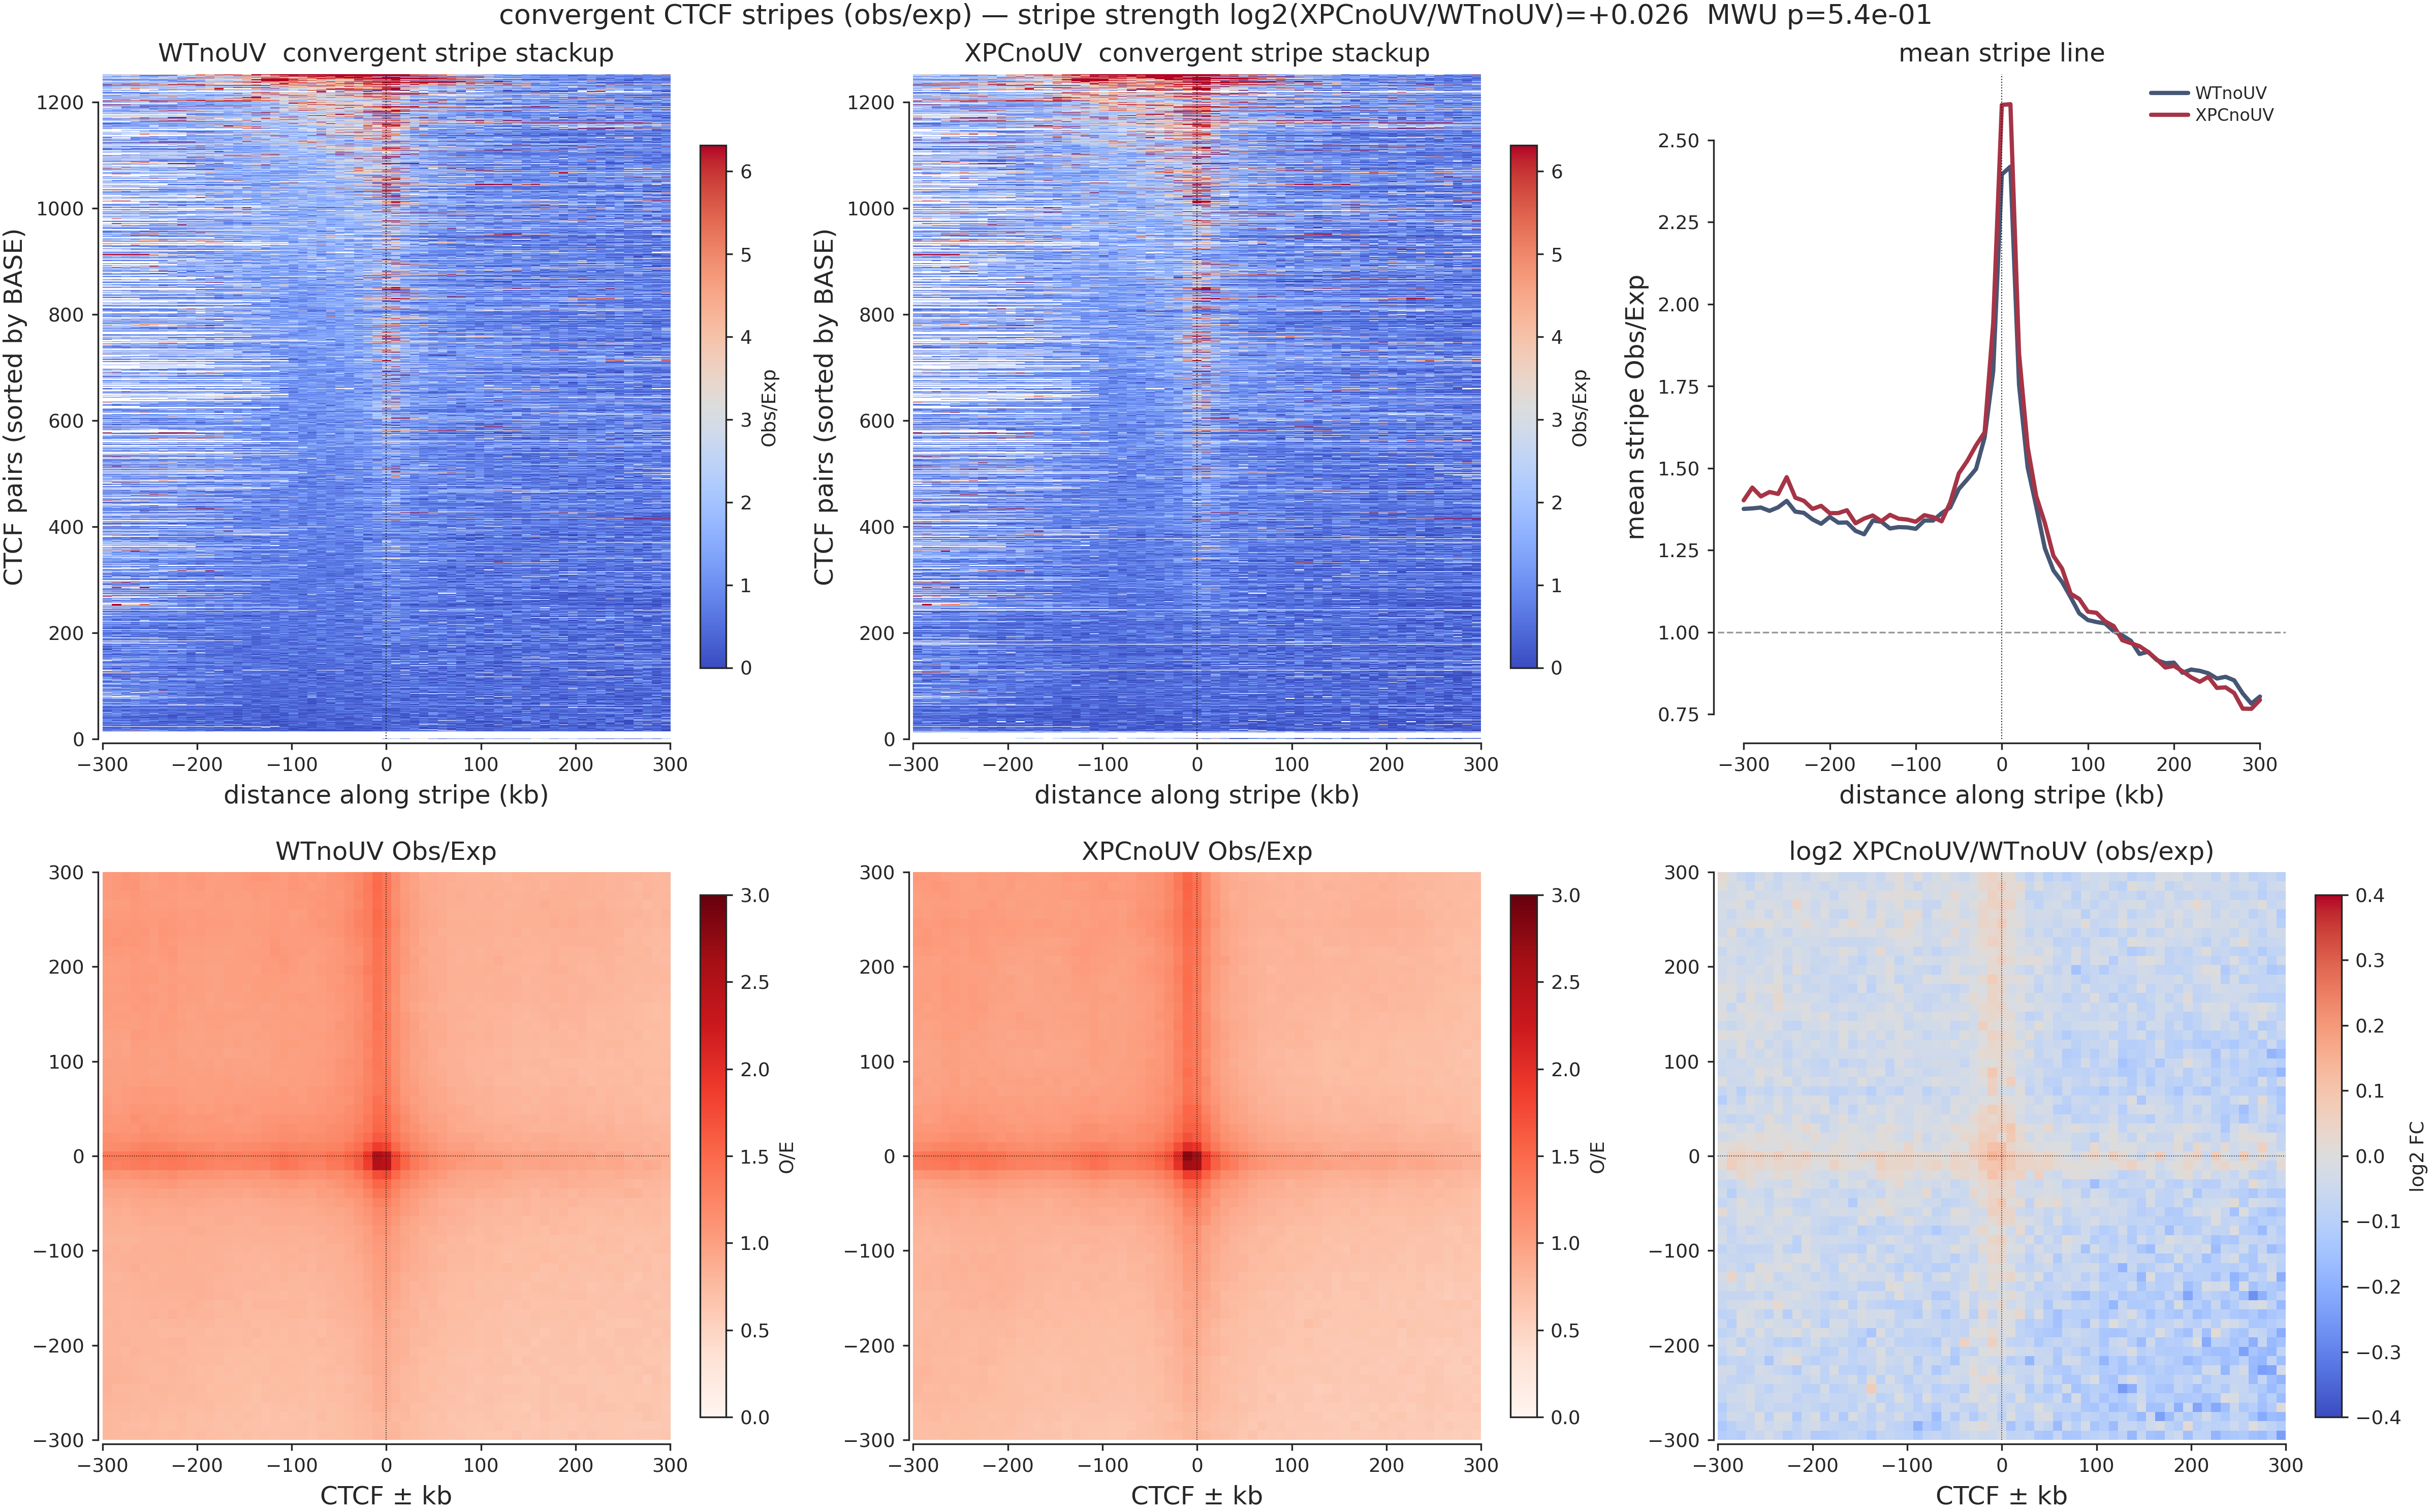

In [4]:
eps = 1e-6
w = vstripe[BASE].shape[1]; c = w // 2
offsets = (np.arange(w) - c) * resolution / 1e3
lo = max(1, int(STRENGTH_LO_KB * 1e3 / resolution))
hi = min(c - 1, int(STRENGTH_HI_KB * 1e3 / resolution))
assert lo < hi, 'STRENGTH band collapses — increase FLANK or lower STRENGTH_LO_KB'

mean_base = np.nanmean(vstripe[BASE], axis=0)
mean_comp = np.nanmean(vstripe[COMP], axis=0)
left = np.arange(c - hi, c - lo + 1); right = np.arange(c + lo, c + hi + 1)
sband = left if np.nanmean(mean_base[left]) >= np.nanmean(mean_base[right]) else right
# per-sample obs/exp strength (each vs its own background) — field standard
sb = np.nanmean(vstripe[BASE][:, sband], axis=1)
sc = np.nanmean(vstripe[COMP][:, sband], axis=1)
order = np.argsort(-np.nan_to_num(sb))
vmax_st = np.nanpercentile(vstripe[BASE], 99)

fig, axs = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

# row 1: sorted stripe stackups + mean lines
for ax, s in zip(axs[0, :2], [BASE, COMP]):
    M = vstripe[s][order]
    im = ax.imshow(M, cmap='coolwarm', vmin=0, vmax=vmax_st, aspect='auto',
                   extent=[offsets[0], offsets[-1], 0, M.shape[0]], interpolation='none')
    ax.axvline(0, color='k', lw=0.5, ls=':')
    ax.set_title(f'{s}  convergent stripe stackup', fontsize=12)
    ax.set_xlabel('distance along stripe (kb)'); ax.set_ylabel('CTCF pairs (sorted by BASE)')
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02); cb.set_label('Obs/Exp', fontsize=9)
    for a in ax.get_images():
        a.set_rasterized(True)
    plotting.despine(ax)
ax = axs[0, 2]
ax.plot(offsets, mean_base, color='#465775', lw=2, label=BASE)
ax.plot(offsets, mean_comp, color='#A63446', lw=2, label=COMP)
ax.axvline(0, color='k', lw=0.5, ls=':'); ax.axhline(1, color='0.6', lw=0.8, ls='--')
ax.set_xlabel('distance along stripe (kb)'); ax.set_ylabel('mean stripe Obs/Exp')
ax.set_title('mean stripe line'); ax.legend(frameon=False); plotting.despine(ax)

# row 2: per-sample obs/exp BASE, COMP, and log2(COMP/BASE)
fl = FLANK / 1e3; ext = [-fl, fl, -fl, fl]
b2d, c2d = data[BASE], data[COMP]
for ax, (title, M, vmin, vmax, cmap, cl) in zip(axs[1], [
    (f'{BASE} Obs/Exp', b2d, 0, 3, 'Reds', 'O/E'),
    (f'{COMP} Obs/Exp', c2d, 0, 3, 'Reds', 'O/E'),
    (f'log2 {COMP}/{BASE} (obs/exp)', np.log2((c2d + eps) / (b2d + eps)), -0.4, 0.4, 'coolwarm', 'log2 FC'),
]):
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, extent=ext, origin='lower', interpolation='none')
    ax.axhline(0, color='k', lw=0.4, ls=':'); ax.axvline(0, color='k', lw=0.4, ls=':')
    ax.set_title(title, fontsize=12); ax.set_xlabel('CTCF ± kb')
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02); cb.set_label(cl, fontsize=9)
    for a in ax.get_images():
        a.set_rasterized(True)
    plotting.despine(ax)

pval = mannwhitneyu(sc[np.isfinite(sc)], sb[np.isfinite(sb)], alternative='two-sided').pvalue
log2fc = np.log2(np.nanmean(sc) / np.nanmean(sb))
fig.suptitle(f'convergent CTCF stripes (obs/exp) — stripe strength log2({COMP}/{BASE})={log2fc:+.3f}  MWU p={pval:.1e}', fontsize=13)
os.makedirs('/home/carlos/Clone/ggner-3d/figs/stripes', exist_ok=True)
fig.savefig('/home/carlos/Clone/ggner-3d/figs/stripes/ctcf_stripes_xpc_over_wt.svg', dpi=300)
fig.savefig('/home/carlos/Clone/ggner-3d/figs/stripes/ctcf_stripes_xpc_over_wt.png', dpi=300)
print(f'stripe strength {BASE} {np.nanmean(sb):.3f}  {COMP} {np.nanmean(sc):.3f}  log2 {log2fc:+.3f}  p={pval:.2e}')

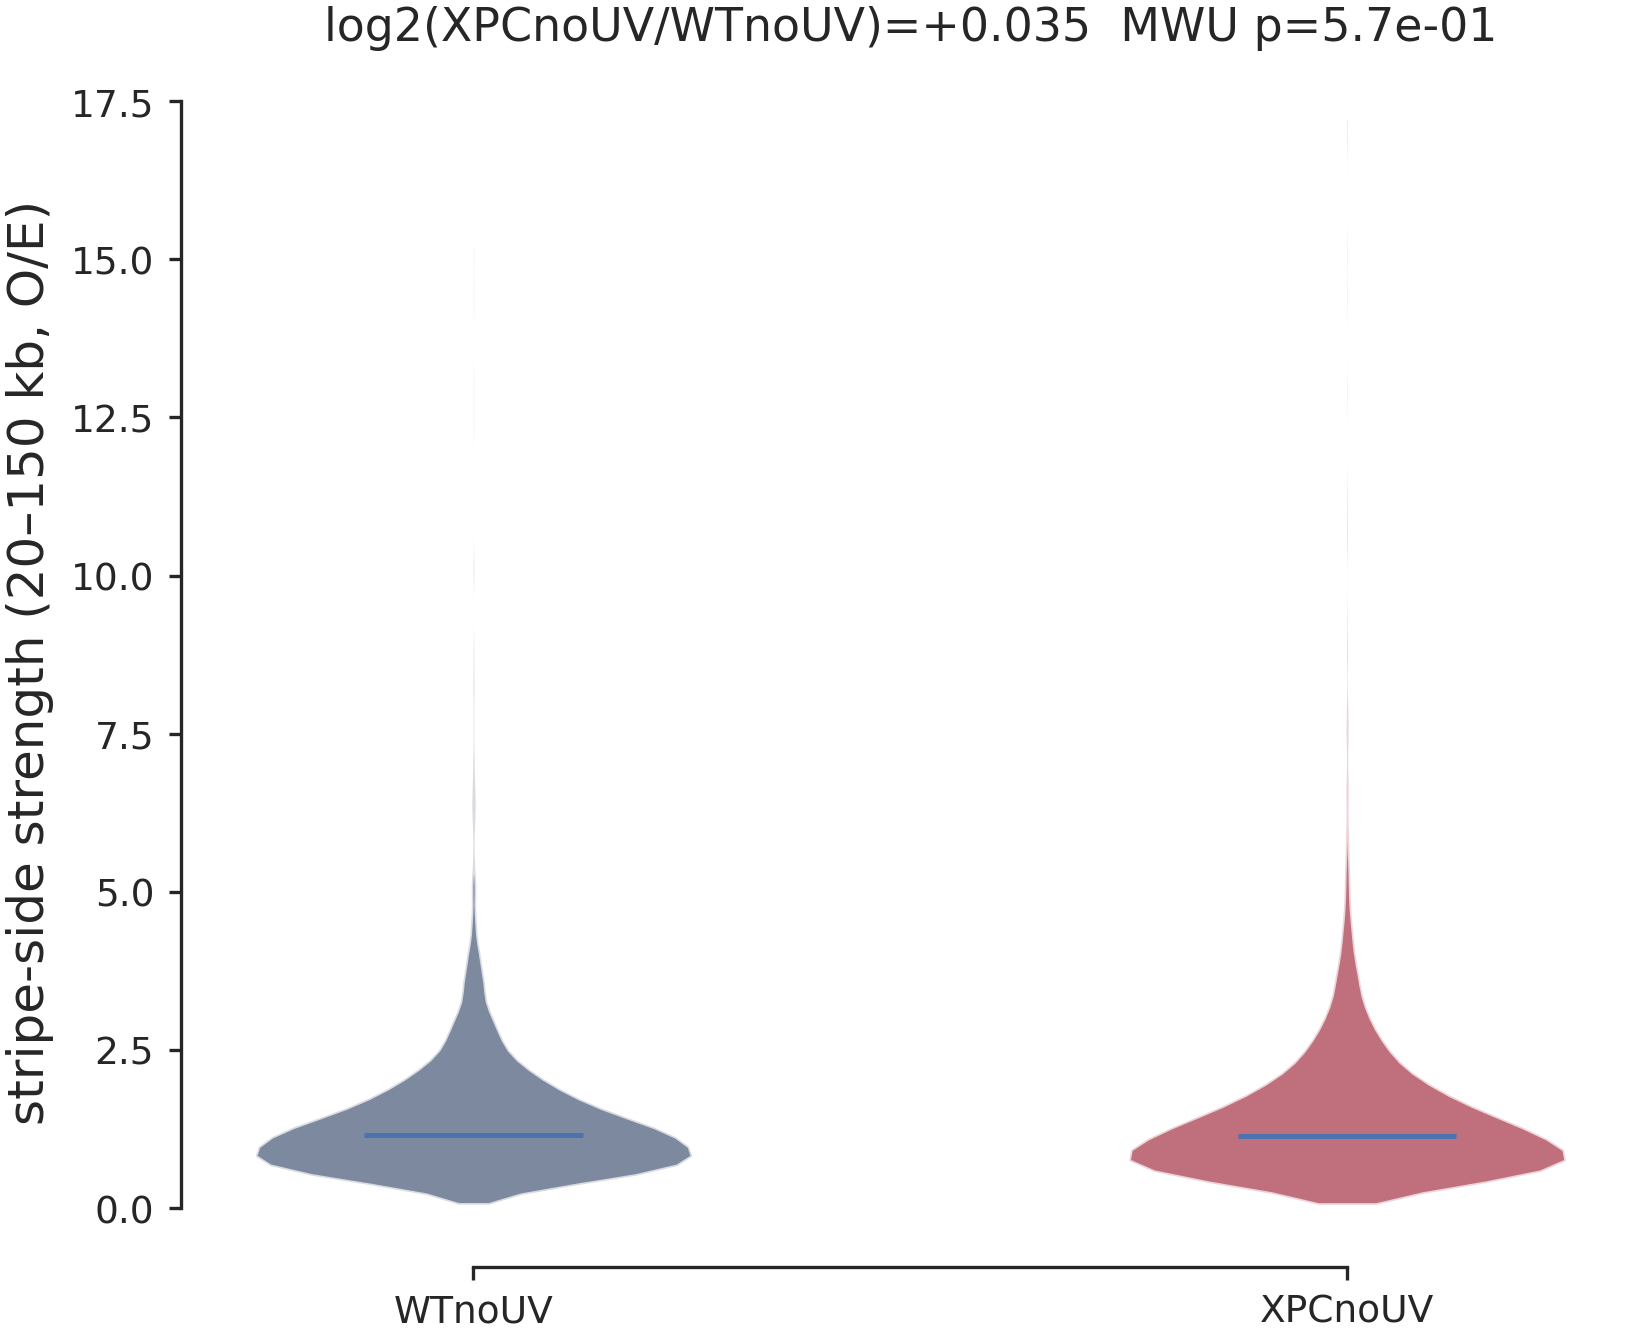

In [10]:
# per-pair stripe strength distribution (the direct 'stronger in COMP?' figure)
fig, ax = plt.subplots(figsize=(5.5, 4.5), constrained_layout=True)
parts = ax.violinplot([sb[np.isfinite(sb)], sc[np.isfinite(sc)]], showmedians=True, showextrema=False)
for pc, col in zip(parts['bodies'], ['#465775', '#A63446']):
    pc.set_facecolor(col); pc.set_alpha(0.7)
ax.set_xticks([1, 2], [BASE, COMP]); ax.set_ylabel(f'stripe-side strength ({STRENGTH_LO_KB}\u2013{STRENGTH_HI_KB} kb, O/E)')
ax.set_title(f'log2({COMP}/{BASE})={log2fc:+.3f}  MWU p={pval:.1e}', fontsize=11)
plotting.despine(ax)
fig.savefig('/home/carlos/Clone/ggner-3d/figs/stripes/ctcf_stripe_strength_xpc_vs_wt.svg', dpi=300)
fig.savefig('/home/carlos/Clone/ggner-3d/figs/stripes/ctcf_stripe_strength_xpc_vs_wt.png', dpi=300)